## ASSIGNMENT 17

In [14]:
'''
Q1. Load the Heart Disease dataset using pandas and display the first 10 rows.
Also check the shape and basic information (info()) of the dataset.
'''

import pandas as pd

# Load the dataset
df = pd.read_csv("heart.csv")

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display shape
print("\nShape of Dataset:")
print(df.shape)

# Display basic information
print("\nDataset Information:")
df.info()

First 10 Rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up        

In [3]:
'''
Q2. Check for missing values in the dataset.
Show the count of null values for each column.
'''

# Display null values
print("Null Values in Each Column:")
print(df.isnull().sum())

Null Values in Each Column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [4]:
'''
Q3. Check for duplicate rows in the dataset.
If any duplicates are found, remove them and print the new shape of the dataset.
'''

# Check duplicate rows
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Display new shape
print("\nNew Shape of Dataset:")
print(df.shape)

Number of Duplicate Rows:
0

New Shape of Dataset:
(918, 12)


In [15]:
'''
Q4. Identify unrealistic/invalid values:

Count how many rows have Cholesterol = 0.
Count how many rows have RestingBP = 0.
Print both counts.
'''

# Count rows where Cholesterol is 0
cholesterol_zero = (df["Cholesterol"] == 0).sum()

# Count rows where RestingBP is 0
restingbp_zero = (df["RestingBP"] == 0).sum()

# Display counts
print("Rows with Cholesterol = 0:")
print(cholesterol_zero)

print("\nRows with RestingBP = 0:")
print(restingbp_zero)

Rows with Cholesterol = 0:
172

Rows with RestingBP = 0:
1


In [7]:
'''
Q5. Clean the invalid values:

Replace Cholesterol = 0 with the mean cholesterol value (excluding zeros).
Replace RestingBP = 0 with the mean resting blood pressure value (excluding zeros).
Round both columns to 2 decimal places.
Print the statistical summary (describe()) of these two columns before and after cleaning.
'''

# Statistical summary before cleaning
print("Before Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

# Calculate mean excluding zeros
cholesterol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
restingbp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

# Replace invalid values with mean
df["Cholesterol"] = df["Cholesterol"].replace(0, cholesterol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, restingbp_mean)

# Round values to 2 decimal places
df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

# Statistical summary after cleaning
print("\nAfter Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

Before Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


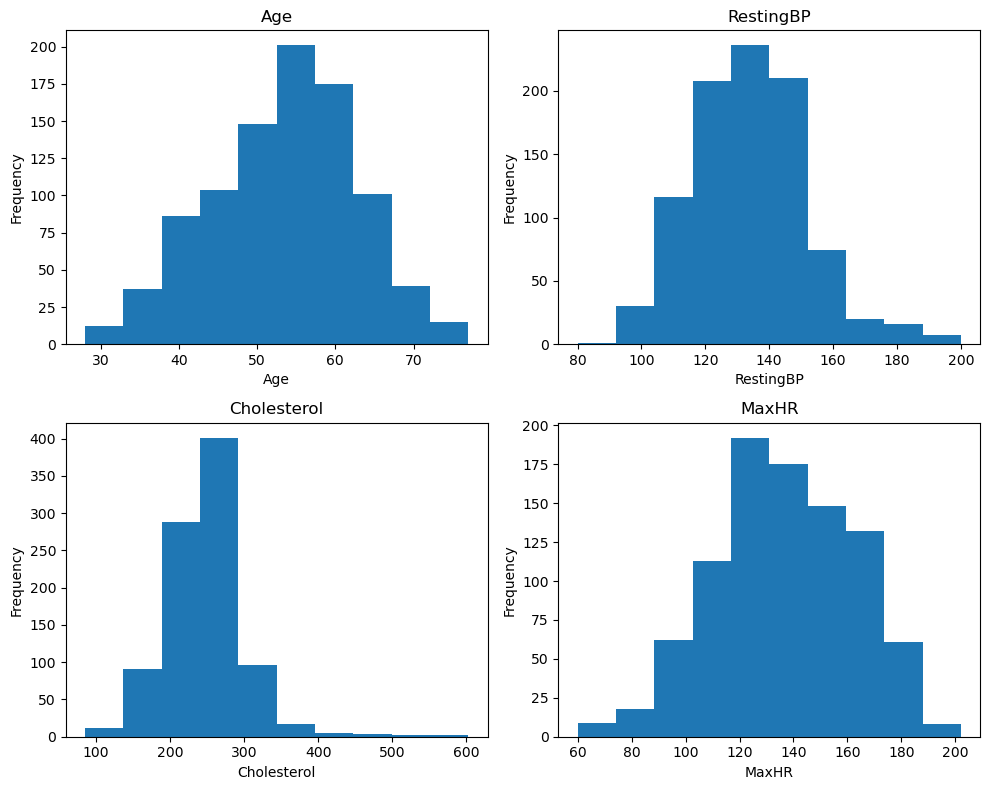

In [9]:
'''
Q6. Create a function to plot histograms for the following numerical columns:

- Age
- RestingBP
- Cholesterol
- MaxHR

Plot all four histograms in one figure using subplots (2x2 layout).
Use this function to visualize the data after cleaning.
'''
# Importing Matplotlib
import matplotlib.pyplot as plt

# Function to plot histograms
def plot_histograms(data):
    
    columns = ["Age", "RestingBP", "Cholesterol", "MaxHR"]
    
    plt.figure(figsize=(10, 8))
    
    for i, column in enumerate(columns, 1):
        plt.subplot(2, 2, i)
        plt.hist(data[column], bins=10)
        plt.title(column)
        plt.xlabel(column)
        plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_histograms(df)

In [10]:
'''
Q7. Identify and print numerical columns and categorical columns separately.
'''

# Identify numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Identify categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

# Display numerical columns
print("Numerical Columns:")
print(numerical_columns)

# Display categorical columns
print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

Categorical Columns:
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [11]:
'''
Q8. Perform One-Hot Encoding on all categorical columns using pd.get_dummies().

Store the result in a new dataframe called df_encoded.
Print the shape and the first 5 rows of the encoded dataframe.
'''

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df)

# Display shape
print("Shape of Encoded DataFrame:")
print(df_encoded.shape)

# Display first 5 rows
print("\nFirst 5 Rows of Encoded DataFrame:")
print(df_encoded.head())

Shape of Encoded DataFrame:
(918, 21)

First 5 Rows of Encoded DataFrame:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             Fals

In [13]:
'''
Q9. After cleaning and encoding:

Print the final shape of df_encoded.
Show the list of all column names in the final dataframe.
'''

# Display final shape
print("Final Shape of Encoded DataFrame:")
print(df_encoded.shape)

# Display column names
print("Column Names:")
print(df_encoded.columns.tolist())

Final Shape of Encoded DataFrame:
(918, 21)
Column Names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


## Analysing Summary

'''
Q10. Summary

1. Invalid Values and Fix
   - I found invalid values where Cholesterol = 0 and RestingBP = 0.
   - I replaced these values with the mean of their respective columns after excluding the zero values.

2. Importance of Handling Invalid Values
   - Invalid values can affect statistical analysis and machine learning model performance.
   - Replacing them with meaningful values improves data quality and reliability.

3. Purpose of One-Hot Encoding
   - One-Hot Encoding converts categorical columns into numerical columns.
   - It helps machine learning algorithms process categorical data correctly.

4. Other Observations
   - The dataset contained no missing values.
   - Duplicate rows were removed before further processing.
   - After cleaning and encoding, the dataset became ready for analysis and machine learning.
'''